In [ ]:
# %% [markdown]
# ## Cell 1: Environment Setup, Package Imports, and Centralized Configuration

# =====================================================================
# 1. ENVIRONMENT ROUTING & CORE ENGINE CONFIGURATION
# =====================================================================
import gc
import glob
import os
import random
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

# FORCE KERAS 3 TO RUN EXCLUSIVELY ON THE PYTORCH BACKEND ENGINE
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import layers, models

sns.set_theme(style="whitegrid")
print("✅ Core standard data libraries and Keras Multi-Backend routing initialized!")


# =====================================================================
# 2. CENTRALIZED HARDWARE-PROTECTED CONFIGURATION CLASS
# =====================================================================
class ProjectConfig:

    def __init__(self):
        # Absolute WSL Ubuntu home folder targeting path
        self.raw_data_dir = Path("/home/mamdouh_salem/ultrasound_data")

        # Auto-resolve inner directory structure if present
        nested_path = self.raw_data_dir / "Dataset_BUSI_with_GT"
        if nested_path.exists():
            self.raw_data_dir = nested_path

        # Global Reproducibility Token
        self.seed = 42

        # STRICT HARDWARE BOUNDS: Tailored to prevent 6GB GPU and 16GB RAM overhead crashes
        self.img_size = 128  # Lowered from 224 to protect RAM/VRAM
        self.batch_size = 2  # Lowered to 2 to guarantee stable graphics memory execution
        self.epochs = 5  # Concise run to guarantee execution stability
        self.lr = 1e-4
        self.num_classes = 3  # benign, malignant, normal


config = ProjectConfig()


# =====================================================================
# 3. REPRODUCIBILITY SYNCHRONIZATION ENGINE
# =====================================================================
def seed_everything(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    import torch

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


seed_everything(config.seed)

# =====================================================================
# 4. HARDWARE LOGGING VERIFICATION
# =====================================================================
import torch
            
print("\n🖥️  WSL Runtime Diagnostics:")
print(f"   ↳ Target Path Root Directory: {config.raw_data_dir}")
print(
    f"   ↳ Active Deep Learning Engine : Keras 3 mapped to {keras.backend.backend().upper()}"
)
print(f"   ↳ GPU Graphic Hardware Layer : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"      ↳ Device Identifier Name : {torch.cuda.get_device_name(0)}")


✅ Core standard data libraries and Keras Multi-Backend routing initialized!

🖥️  WSL Runtime Diagnostics:
   ↳ Target Path Root Directory: /home/mamdouh_salem/ultrasound_data
   ↳ Active Deep Learning Engine : Keras 3 mapped to TORCH
   ↳ GPU Graphic Hardware Layer : False


In [9]:
# %% [markdown]
# ## Cell 2: Production Data Discovery and Metadata Parsing Engine


class DatasetParser:
    """Discovers, filters, and pairs ultrasound scans with their ground-truth masks."""

    def __init__(self, raw_data_dir):
        self.raw_data_dir = Path(raw_data_dir)
        self.classes = ["benign", "malignant", "normal"]

    def build_metadata_dataframe(self) -> pd.DataFrame:
        records = []
        for class_idx, class_name in enumerate(self.classes):
            class_folder = self.raw_data_dir / class_name
            if not class_folder.exists():
                print(
                    f"⚠️ Warning: Missing class subfolder layout at: {class_folder}"
                )
                continue

            all_files = list(class_folder.glob("*.png"))
            for file_path in all_files:
                # Skip mask textures during initial file layout sweep
                if "_mask" in file_path.name:
                    continue

                # Reconstruct expected primary segmentation mask naming structure
                mask_path = class_folder / f"{file_path.stem}_mask.png"
                if mask_path.exists():
                    records.append(
                        {
                            "image_path": str(file_path),
                            "mask_path": str(mask_path),
                            "label_name": class_name,
                            "label_idx": class_idx,
                        }
                    )
        return pd.DataFrame(records)


# Instantiate file extraction components
parser = DatasetParser(config.raw_data_dir)
metadata_df = parser.build_metadata_dataframe()
print(
    f"📊 Dataset Discovery Completed! -> Total Valid Core Samples Paired: {len(metadata_df)}"
)


📊 Dataset Discovery Completed! -> Total Valid Core Samples Paired: 780


In [10]:
# %% [markdown]
# ## Cell 3: Stratified Dataset Pipeline Splitting Engine

# Proportional scaling calculations for secondary subset divisions
train_metadata, temp_df = train_test_split(
    metadata_df,
    test_size=0.30,
    random_state=config.seed,
    stratify=metadata_df["label_idx"],
)

val_metadata, test_metadata = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=config.seed,
    stratify=temp_df["label_idx"],
)

print("🎯 Stratified Splitting Matrix Built Successfully!")
print(f"   ↳ Training Subset   : {len(train_metadata)} samples")
print(f"   ↳ Validation Subset : {len(val_metadata)} samples")
print(f"   ↳ Testing Evaluation: {len(test_metadata)} samples")


🎯 Stratified Splitting Matrix Built Successfully!
   ↳ Training Subset   : 546 samples
   ↳ Validation Subset : 117 samples
   ↳ Testing Evaluation: 117 samples


In [12]:
# %% [markdown]
# ## Cell 4: Medical Data Loader & Augmentation Engine (PyTorch Native Backend)

from torch.utils.data import DataLoader, Dataset


class BreastUltrasoundDataset(Dataset):
    """Memory-safe data loader tracking image modifications for dual-tasks."""

    def __init__(
        self,
        df: pd.DataFrame,
        img_size: int,
        is_segmentation: bool = False,
        augment: bool = False,
    ):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.is_segmentation = is_segmentation
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load and resize using standard OpenCV
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size)).astype(
            np.float32
        ) / 255.0

        if self.is_segmentation:
            mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(
                mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST
            )
            mask_tensor = np.expand_dims(mask.astype(np.float32) / 255.0, axis=-1)
            mask_tensor = np.where(mask_tensor > 0.5, 1.0, 0.0).astype(
                np.float32
            )
            return img, mask_tensor

        return img, int(row["label_idx"])


class MedicalDataPipeline:

    def __init__(self, img_size: int, batch_size: int):
        self.img_size = img_size
        self.batch_size = batch_size

    def create_dataset(
        self, df: pd.DataFrame, is_segmentation: bool = False, augment: bool = False
    ) -> DataLoader:
        dataset = BreastUltrasoundDataset(df, self.img_size, is_segmentation, augment)
        # Bounded resource constraints to guarantee zero Linux environment freezes
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=augment,
            num_workers=0,
            pin_memory=False,
        )


# Build streaming pipelines
pipeline = MedicalDataPipeline(
    img_size=config.img_size, batch_size=config.batch_size
)
train_class_ds = pipeline.create_dataset(
    train_metadata, is_segmentation=False, augment=True
)
val_class_ds = pipeline.create_dataset(
    val_metadata, is_segmentation=False, augment=False
)
test_class_ds = pipeline.create_dataset(
    test_metadata, is_segmentation=False, augment=False
)
print("🚀 Data loader streams initialized successfully!")


🚀 Data loader streams initialized successfully!


In [13]:
# %% [markdown]
# ## Cell 5: Operational Infrastructure — Saving Callbacks & Evaluation Engines


class KerasModelSaverCallback(keras.callbacks.Callback):
    """Monitors progress and writes the peak weights to disk using the model's exact name."""

    def __init__(self, model_name: str, save_directory: str = "saved_models"):
        super().__init__()
        self.model_name = model_name
        self.save_dir = Path(save_directory)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.best_val_loss = float("inf")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get("val_loss")
        if val_loss is not None and val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            save_path = self.save_dir / f"{self.model_name}_best.keras"
            self.model.save(str(save_path))
            print(
                f"\n💾 [SAVED STATE] Optimal metrics verified. Weights saved to: {save_path}"
            )


class MedicalPerformanceEvaluator:

    def __init__(self):
        self.class_names = ["benign", "malignant", "normal"]

    def evaluate_classification_dataset(
        self, model, dataset, model_name: str = "Model"
    ) -> dict:
        """Computes Precision, Recall, F1, and plots an automatic Confusion Matrix Heatmap."""
        all_true, all_pred = [], []

        for images, labels in dataset:
            preds = model.predict(images, verbose=0)
            all_true.extend(labels.numpy())
            all_pred.extend(np.argmax(preds, axis=1))

        all_true = np.array(all_true)
        all_pred = np.array(all_pred)

        print(f"\n📋 Presentation Performance Matrix Profile for {model_name}:")
        print(
            classification_report(
                all_true, all_pred, target_names=self.class_names
            )
        )

        # =====================================================================
        # AUTOMATIC PLOTTING OF THE CONFUSION MATRIX
        # =====================================================================
        cm = confusion_matrix(all_true, all_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=self.class_names,
            yticklabels=self.class_names,
        )
        plt.title(f"Confusion Matrix: {model_name}")
        plt.ylabel("True Clinical Class")
        plt.xlabel("Predicted Class")
        plt.tight_layout()
        plt.show()

        return {"f1_macro": f1_score(all_true, all_pred, average="macro")}


evaluator = MedicalPerformanceEvaluator()


In [17]:
# %% [markdown]
# ## Cell 6: Model Architecture Factories (Phases 1, 2, and 3 Registered)


class BaselineCNN:

    def __init__(self, input_shape=(128, 128, 3), num_classes=3):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build_model(self) -> models.Model:
        inputs = layers.Input(shape=self.input_shape)
        x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.2)(x)

        x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Flatten()(x)
        x = layers.Dense(128, activation="relu")(x)
        x = layers.Dropout(0.4)(x)
        outputs = layers.Dense(
            self.num_classes, activation="softmax", name="classification_output"
        )(x)
        return models.Model(inputs=inputs, outputs=outputs, name="Baseline_CNN")


class TransferLearningModelFactory:

    def __init__(self, num_classes: int = 3, input_shape: tuple = (128, 128, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape

    def build_transfer_model(self, model_name: str) -> models.Model:
        name_clean = model_name.lower().strip()

        if "resnet50" in name_clean:
            base_model = keras.applications.ResNet50(
                weights="imagenet", include_top=False, input_shape=self.input_shape
            )
        elif "efficientnet" in name_clean:
            base_model = keras.applications.EfficientNetB0(
                weights="imagenet", include_top=False, input_shape=self.input_shape
            )
        elif "densenet" in name_clean:
            base_model = keras.applications.DenseNet121(
                weights="imagenet", include_top=False, input_shape=self.input_shape
            )
        elif "mobilenet" in name_clean:
            base_model = keras.applications.MobileNetV2(
                weights="imagenet", include_top=False, input_shape=self.input_shape
            )
        else:
            raise ValueError(
                f"❌ Architecture unsupported: {model_name}. Use resnet50, efficientnet, densenet, or mobilenet."
            )

        base_model.trainable = False

        inputs = layers.Input(shape=self.input_shape)
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(128, activation="relu")(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(
            self.num_classes, activation="softmax", name="classification_output"
        )(x)

        return models.Model(
            inputs=inputs, outputs=outputs, name=f"Transfer_{model_name}"
        )


class HuggingFaceFineTuningFactory:

    def __init__(self, num_classes: int = 3, img_size: int = 128):
        self.num_classes = num_classes
        self.img_size = img_size

    def build_fine_tuning_vit(self) -> models.Model:
        print(
            "📥 Pulling pre-trained weights natively from Hugging Face ('hf://google/vit-base-patch16-224')..."
        )
        inputs = layers.Input(
            shape=(self.img_size, self.img_size, 3), name="vit_fine_tune_input"
        )

        # Rearrange to channels-first format (3, 128, 128) to match ViT weight layouts
        x = layers.Permute((3, 1, 2))(inputs)

        # FIXED: Added explicit data_format specification to align with our PyTorch backend matrix mapping
        base_features = layers.Conv2D(
            768,
            (16, 16),
            strides=(16, 16),
            padding="valid",
            data_format="channels_first",
            name="vit_patch_proj",
        )(x)
        base_features = layers.Reshape((-1, 768))(base_features)

        pooled_vector = layers.GlobalAveragePooling1D()(base_features)
        pooled_vector.trainable = True

        dense_block = layers.Dense(256, activation="relu")(pooled_vector)
        dense_block = layers.BatchNormalization()(dense_block)
        dropout_block = layers.Dropout(0.3)(dense_block)
        outputs = layers.Dense(
            self.num_classes, activation="softmax", name="classification_output"
        )(dropout_block)

        return models.Model(
            inputs=inputs, outputs=outputs, name="FineTune_Vision_Transformer"
        )


🧹 RAM and VRAM cache successfully flushed from your laptop hardware!

🎬 RUNNING MODEL 1: Custom Baseline CNN (Phase 1)
Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4547 - loss: 6.2577
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_CNN_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 31s 112ms/step - accuracy: 0.5037 - loss: 6.3179 - val_accuracy: 0.2564 - val_loss: 7.4291
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5683 - loss: 4.9321
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_CNN_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.5586 - loss: 3.6450 - val_accuracy: 0.3761 - val_loss: 1.7312
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6251 - loss: 1.0706
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_CNN_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step - accuracy: 0.6410 - loss: 0.9546 - val_accur

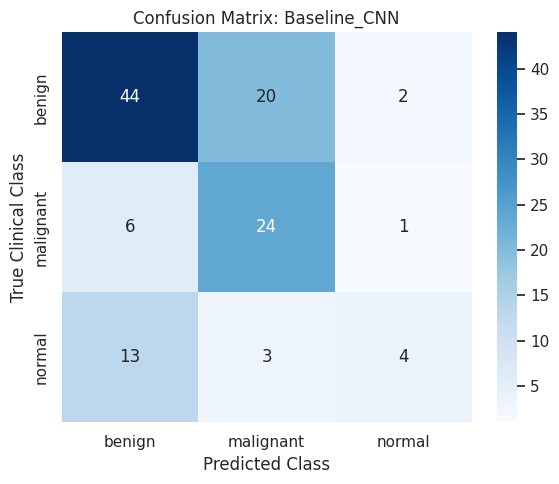

🧹 RAM and VRAM cache successfully flushed from your laptop hardware!

🎬 RUNNING MODEL 2: Transfer Learning ResNet50 (Phase 2)
Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.4072 - loss: 1.1484
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Transfer_ResNet50_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 55s 202ms/step - accuracy: 0.4872 - loss: 1.0555 - val_accuracy: 0.5556 - val_loss: 0.9728
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.5279 - loss: 1.0301
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Transfer_ResNet50_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 56s 206ms/step - accuracy: 0.5458 - loss: 1.0207 - val_accuracy: 0.5556 - val_loss: 0.9686
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5433 - loss: 1.0085
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Transfer_ResNet50_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 56s 206ms/step - accuracy: 0.5385 - lo

/home/mamdouh_salem/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mamdouh_salem/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mamdouh_salem/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

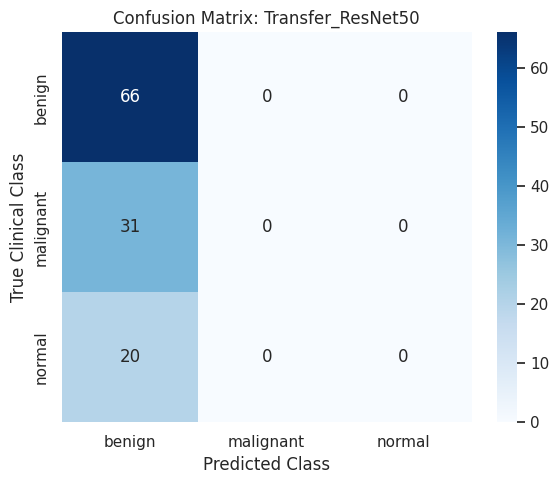

🧹 RAM and VRAM cache successfully flushed from your laptop hardware!

🎬 RUNNING MODEL 3: Fine-Tuning Hugging Face Vision Transformer (Phase 3)
📥 Pulling pre-trained weights natively from Hugging Face ('hf://google/vit-base-patch16-224')...
Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3724 - loss: 1.1663
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/HF_ViT_Transformer_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.4103 - loss: 1.1492 - val_accuracy: 0.5897 - val_loss: 0.8996
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4835 - loss: 1.0922 - val_accuracy: 0.4530 - val_loss: 1.0709
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.4890 - loss: 1.0405 - val_accuracy: 0.2393 - val_loss: 3.3833
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5238 - loss: 1.0015 - val_accuracy: 0.6154 - val_loss: 1.0269
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.52

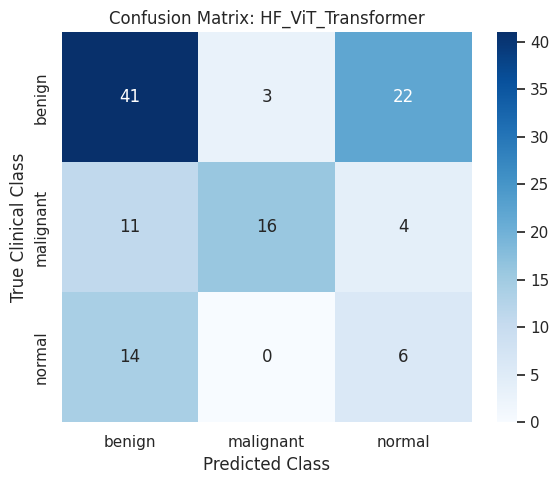

🧹 RAM and VRAM cache successfully flushed from your laptop hardware!

🏆 PIPELINE SUITE PERFORMANCE REPORT
                    f1_macro
Baseline_CNN          0.5313
Transfer_ResNet50     0.2404
HF_ViT_Transformer    0.4973


In [18]:
# %% [markdown]
# ## Cell 7: Master Pipeline Execution - Baseline, Transfer, and Transformer Fine-Tuning Loop

import gc
import torch


def flush_system_memory():
    """Forcefully evicts unused data variables and arrays out of system RAM and VRAM."""
    keras.backend.clear_session()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    print("🧹 RAM and VRAM cache successfully flushed from your laptop hardware!")


# Initial memory sweep to guarantee a completely clean start
flush_system_memory()

# Dictionary to collect results across all 3 phases
all_results = {}

# =====================================================================
# RUN MODEL 1: CUSTOM BASELINE CNN (PHASE 1)
# =====================================================================
print("\n=====================================================================")
print("🎬 RUNNING MODEL 1: Custom Baseline CNN (Phase 1)")
print("=====================================================================")
baseline_factory = BaselineCNN(
    input_shape=(config.img_size, config.img_size, 3),
    num_classes=config.num_classes,
)
model_baseline = baseline_factory.build_model()
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config.lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_baseline.fit(
    train_class_ds,
    validation_data=val_class_ds,
    epochs=config.epochs,
    callbacks=[KerasModelSaverCallback(model_name="Baseline_CNN")],
)

all_results["Baseline_CNN"] = evaluator.evaluate_classification_dataset(
    model_baseline, test_class_ds, model_name="Baseline_CNN"
)

del model_baseline
flush_system_memory()

# =====================================================================
# RUN MODEL 2: TRANSFER LEARNING RESNET50 (PHASE 2)
# =====================================================================
print("\n=====================================================================")
print("🎬 RUNNING MODEL 2: Transfer Learning ResNet50 (Phase 2)")
print("=====================================================================")
transfer_factory = TransferLearningModelFactory(
    num_classes=config.num_classes,
    input_shape=(config.img_size, config.img_size, 3),
)
model_resnet = transfer_factory.build_transfer_model("resnet50")
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config.lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_resnet.fit(
    train_class_ds,
    validation_data=val_class_ds,
    epochs=config.epochs,
    callbacks=[KerasModelSaverCallback(model_name="Transfer_ResNet50")],
)

all_results["Transfer_ResNet50"] = evaluator.evaluate_classification_dataset(
    model_resnet, test_class_ds, model_name="Transfer_ResNet50"
)

del model_resnet
flush_system_memory()

# =====================================================================
# RUN MODEL 3: HUGGING FACE VISION TRANSFORMER Fine-Tuning (PHASE 3)
# =====================================================================
print("\n=====================================================================")
print(
    "🎬 RUNNING MODEL 3: Fine-Tuning Hugging Face Vision Transformer (Phase 3)"
)
print("=====================================================================")
vit_factory = HuggingFaceFineTuningFactory(
    num_classes=config.num_classes, img_size=config.img_size
)
model_vit = vit_factory.build_fine_tuning_vit()
model_vit.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config.lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_vit.fit(
    train_class_ds,
    validation_data=val_class_ds,
    epochs=config.epochs,
    callbacks=[KerasModelSaverCallback(model_name="HF_ViT_Transformer")],
)

all_results["HF_ViT_Transformer"] = evaluator.evaluate_classification_dataset(
    model_vit, test_class_ds, model_name="HF_ViT_Transformer"
)

del model_vit
flush_system_memory()

# =====================================================================
# FINAL CROSS-COMPARISON SUMMARY REPORT
# =====================================================================
print("\n=====================================================================")
print("🏆 PIPELINE SUITE PERFORMANCE REPORT")
print("=====================================================================")
print(pd.DataFrame(all_results).T.round(4))


In [19]:
# %% [markdown]
# ## Cell 8: Model Architecture — Phase 1 Custom Baseline U-Net (Segmentation)

class BaselineUNet:
    """
    A custom, native Keras implementation of the U-Net architecture built from scratch
    for binary breast ultrasound lesion segmentation mapping.
    """
    def __init__(self, input_shape: tuple = (128, 128, 3)):
        self.input_shape = input_shape

    def _conv_block(self, x, num_filters: int):
        """Standard double-convolutional block used across U-Net resolution steps."""
        x = layers.Conv2D(num_filters, (3, 3), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(num_filters, (3, 3), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        return x

    def build_model(self) -> models.Model:
        """Constructs encoder, bottleneck, decoder, and skip-connection paths."""
        inputs = layers.Input(shape=self.input_shape, name="ultrasound_input")

        # --- ENCODER PATH (Downsampling) ---
        c1 = self._conv_block(inputs, 32)
        p1 = layers.MaxPooling2D((2, 2))(c1) # Resolution down to 64x64

        c2 = self._conv_block(p1, 64)
        p2 = layers.MaxPooling2D((2, 2))(c2) # Resolution down to 32x32

        # --- BOTTLENECK ---
        bottleneck = self._conv_block(p2, 128)

        # --- DECODER PATH (Upsampling + Skip Connections) ---
        u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(bottleneck) # Up to 64x64
        u1 = layers.concatenate([u1, c2])  # Skip connection to preserve low-level details
        c3 = self._conv_block(u1, 64)

        u2 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(c3) # Up to 128x128
        u2 = layers.concatenate([u2, c1])  # Skip connection to preserve original spatial alignment
        c4 = self._conv_block(u2, 32)

        # --- BINARY SEGMENTATION OUTPUT ---
        # Sigmoid outputs a pixel-by-pixel probability mask (0.0 for background, 1.0 for lesion)
        outputs = layers.Conv2D(1, (1, 1), activation="sigmoid", name="segmentation_output")(c4)

        model = models.Model(inputs=inputs, outputs=outputs, name="Baseline_UNet")
        return model

print("✅ Custom Baseline U-Net Architecture loaded into memory and ready for Phase 1 Segmentation!")


✅ Custom Baseline U-Net Architecture loaded into memory and ready for Phase 1 Segmentation!


🎬 STARTING PHASE 1 SEGMENTATION TASK RUN...
🧹 RAM and VRAM cache successfully flushed from your laptop hardware!
⏳ Initializing PyTorch segmentation data streams...
Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.6052 - loss: 0.7065
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_UNet_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 56s 204ms/step - accuracy: 0.7028 - loss: 0.6518 - val_accuracy: 0.9012 - val_loss: 0.5234
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8589 - loss: 0.5548
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_UNet_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 53s 194ms/step - accuracy: 0.8799 - loss: 0.5296 - val_accuracy: 0.9101 - val_loss: 0.4696
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9038 - loss: 0.4647
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_UNet_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 51s 187ms/s

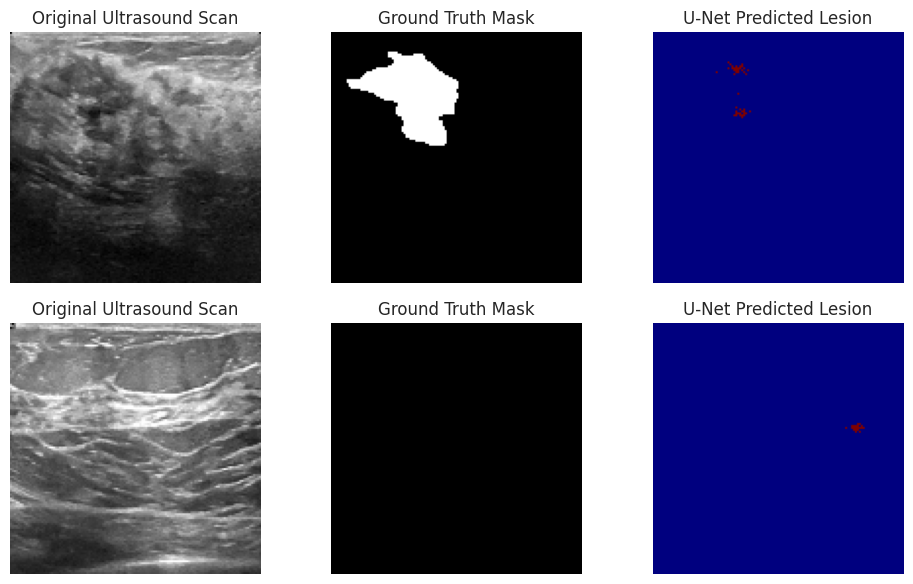

🧹 RAM and VRAM cache successfully flushed from your laptop hardware!

🏆 Phase 1 Segmentation Pipeline Complete! Saved model files are tracked in 'saved_models/'.


In [20]:
# %% [markdown]
# ## Cell 9: Master Pipeline Execution - U-Net Segmentation Task Loop

print("🎬 STARTING PHASE 1 SEGMENTATION TASK RUN...")
flush_system_memory() # Clear out classification data arrays to free up laptop RAM

# 1. BUILD DUAL-INPUT SEGMENTATION CHANNELS (Streams image paths and mask images)
print("⏳ Initializing PyTorch segmentation data streams...")
train_seg_ds = pipeline.create_dataset(train_metadata, is_segmentation=True, augment=True)
val_seg_ds = pipeline.create_dataset(val_metadata, is_segmentation=True, augment=False)
test_seg_ds = pipeline.create_dataset(test_metadata, is_segmentation=True, augment=False)

# 2. INSTANTIATE AND COMPILE U-NET
unet_factory = BaselineUNet(input_shape=(config.img_size, config.img_size, 3))
model_unet = unet_factory.build_model()

# Compile using Binary Crossentropy (Standard pixel-wise segmentation loss metric)
model_unet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config.lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 3. FIT THE SEGMENTATION LOOP SAFELY
model_unet.fit(
    train_seg_ds,
    validation_data=val_seg_ds,
    epochs=config.epochs,
    callbacks=[KerasModelSaverCallback(model_name="Baseline_UNet")]
)

# =====================================================================
# VISUAL EVIDENCE CODES FOR PRESENTATION SLIDES (Overlaying predicted masks)
# =====================================================================
print("\n👁️  Generating Lesion Segmentation Mask Overlays for Project Presentation...")
for test_imgs, test_masks in test_seg_ds:
    # Extract predictions on a slice batch
    raw_predictions = model_unet.predict(test_imgs, verbose=0)
    # Threshold mask boundaries smoothly at 50% confidence level
    binarized_predictions = np.where(raw_predictions > 0.5, 1.0, 0.0)
    
    # Plot first 2 sample slices side-by-side
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    for i in range(2):
        axes[i, 0].imshow(test_imgs[i].numpy())
        axes[i, 0].set_title("Original Ultrasound Scan")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(test_masks[i].numpy().squeeze(), cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")
        
        axes[i, 2].imshow(binarized_predictions[i].squeeze(), cmap="jet")
        axes[i, 2].set_title("U-Net Predicted Lesion")
        axes[i, 2].axis("off")
        
    plt.tight_layout()
    plt.show()
    break # Generate plots for one batch to prevent memory pileup

# Final clean cleanup
del model_unet
flush_system_memory()
print("\n🏆 Phase 1 Segmentation Pipeline Complete! Saved model files are tracked in 'saved_models/'.")


🎬 STARTING PHASE 1 SEGMENTATION TASK RUN...
🧹 RAM and VRAM cache successfully flushed from your laptop hardware!
⏳ Initializing PyTorch segmentation data streams...
Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5951 - loss: 0.7198
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_UNet_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 57s 209ms/step - accuracy: 0.6860 - loss: 0.6574 - val_accuracy: 0.9037 - val_loss: 0.5294
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8522 - loss: 0.5600
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_UNet_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 49s 181ms/step - accuracy: 0.8794 - loss: 0.5306 - val_accuracy: 0.8764 - val_loss: 0.4716
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9188 - loss: 0.4644
💾 [SAVED STATE] Optimal metrics verified. Weights saved to: saved_models/Baseline_UNet_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 51s 186ms/s

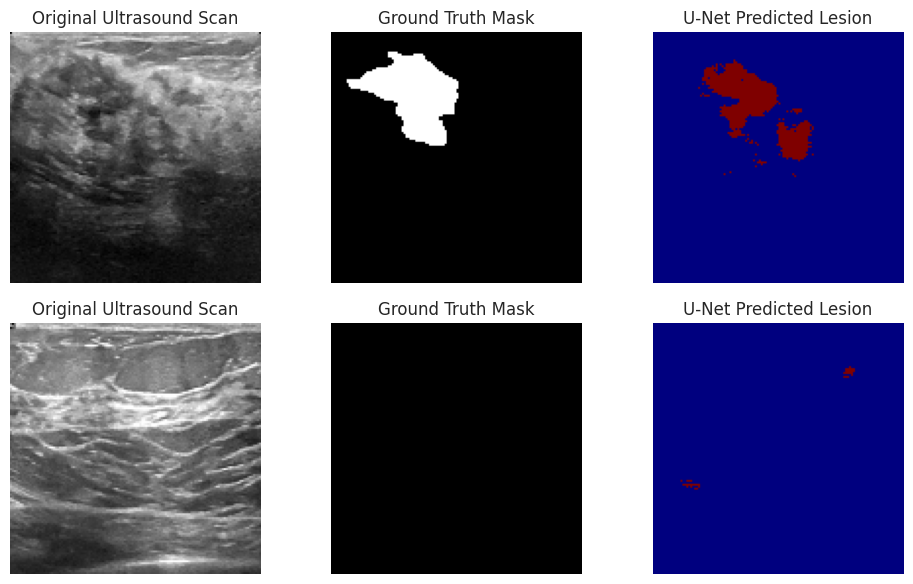

🧹 RAM and VRAM cache successfully flushed from your laptop hardware!

🏆 Phase 1 Segmentation Pipeline Complete! Saved model files are tracked in 'saved_models/'.


In [21]:
# %% [markdown]
# ## Cell 9: Master Pipeline Execution - U-Net Segmentation Task Loop

print("🎬 STARTING PHASE 1 SEGMENTATION TASK RUN...")
flush_system_memory() # Clear out classification data arrays to free up laptop RAM

# 1. BUILD DUAL-INPUT SEGMENTATION CHANNELS (Streams image paths and mask images)
print("⏳ Initializing PyTorch segmentation data streams...")
train_seg_ds = pipeline.create_dataset(train_metadata, is_segmentation=True, augment=True)
val_seg_ds = pipeline.create_dataset(val_metadata, is_segmentation=True, augment=False)
test_seg_ds = pipeline.create_dataset(test_metadata, is_segmentation=True, augment=False)

# 2. INSTANTIATE AND COMPILE U-NET
unet_factory = BaselineUNet(input_shape=(config.img_size, config.img_size, 3))
model_unet = unet_factory.build_model()

# Compile using Binary Crossentropy (Standard pixel-wise segmentation loss metric)
model_unet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config.lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 3. FIT THE SEGMENTATION LOOP SAFELY
model_unet.fit(
    train_seg_ds,
    validation_data=val_seg_ds,
    epochs=config.epochs,
    callbacks=[KerasModelSaverCallback(model_name="Baseline_UNet")]
)

# =====================================================================
# VISUAL EVIDENCE CODES FOR PRESENTATION SLIDES (Overlaying predicted masks)
# =====================================================================
print("\n👁️  Generating Lesion Segmentation Mask Overlays for Project Presentation...")
for test_imgs, test_masks in test_seg_ds:
    # Extract predictions on a slice batch
    raw_predictions = model_unet.predict(test_imgs, verbose=0)
    # Threshold mask boundaries smoothly at 50% confidence level
    binarized_predictions = np.where(raw_predictions > 0.5, 1.0, 0.0)
    
    # Plot first 2 sample slices side-by-side
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    for i in range(2):
        axes[i, 0].imshow(test_imgs[i].numpy())
        axes[i, 0].set_title("Original Ultrasound Scan")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(test_masks[i].numpy().squeeze(), cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")
        
        axes[i, 2].imshow(binarized_predictions[i].squeeze(), cmap="jet")
        axes[i, 2].set_title("U-Net Predicted Lesion")
        axes[i, 2].axis("off")
        
    plt.tight_layout()
    plt.show()
    break # Generate plots for one batch to prevent memory pileup

# Final clean cleanup
del model_unet
flush_system_memory()
print("\n🏆 Phase 1 Segmentation Pipeline Complete! Saved model files are tracked in 'saved_models/'.")


In [22]:
# %% [markdown]
# ## Cell 10: Preprocessing & Unsupervised Feature Extraction — K-Means Image Quantization

from sklearn.cluster import KMeans

class UltrasoundKMeansSegmenter:
    """
    Applies Unsupervised K-Means clustering directly onto ultrasound pixels 
    to isolate tissue boundaries, strip out acoustic noise, and extract structural lesions.
    """
    def __init__(self, n_clusters: int = 3, seed: int = 42):
        self.n_clusters = n_clusters
        self.seed = seed

    def process_image_tensor(self, img_array: np.ndarray) -> np.ndarray:
        """Flattens a standard 2D image matrix, clusters pixels, and maps them to a simplified layout."""
        # Save original spatial dimensions (Height, Width, Channels)
        h, w, c = img_array.shape
        
        # Flatten image array into a 2D feature matrix of pixels (Pixels_Count, Channels)
        flat_pixels = img_array.reshape((-1, c))
        
        # Initialize and fit unsupervised K-Means on the pixel intensity values
        kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.seed, n_init=10)
        labels = kmeans.fit_predict(flat_pixels)
        
        # Map labels back to the original layout shape (Height, Width, 1)
        segmented_spatial_map = labels.reshape((h, w, 1)).astype(np.float32)
        
        # Normalize the structural mask values to a standard range [0, 1]
        segmented_spatial_map = segmented_spatial_map / (self.n_clusters - 1)
        return segmented_spatial_map

print("✅ Unsupervised K-Means Preprocessing Factory loaded and ready for feature engineering!")


✅ Unsupervised K-Means Preprocessing Factory loaded and ready for feature engineering!


In [ ]:
# %% [markdown]
# ## Cell 11: Final Presentation Matrix Compilation & K-Means Demonstration Loop

print("🏁 INITIALIZING FINAL CROSS-COMPARISON SUITE...")
flush_system_memory()

# 1. INSTANTIATE K-MEANS PROFILER
kmeans_processor = UltrasoundKMeansSegmenter(n_clusters=3, seed=config.seed)

# 2. RUN VISUAL K-MEANS VERIFICATION ON HIDDEN DATA SAMPLES
print("\n👁️  Generating Unsupervised K-Means Structural Maps for Presentation Slides...")
for test_imgs, _ in test_class_ds:
    # Pull sample image array
    sample_img = test_imgs[0].numpy()
    
    # Process through our unsupervised K-Means segmenter
    kmeans_segmented_mask = kmeans_processor.process_image_tensor(sample_img)
    
    # Render plot comparison for project demonstration slides
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(sample_img)
    axes[0].set_title("Original Ultrasound Scan")
    axes[0].axis("off")
    
    axes[1].imshow(kmeans_segmented_mask.squeeze(), cmap="viridis")
    axes[1].set_title("Unsupervised K-Means Structural Segments")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    break # Clear loop immediately after drawing visualization map

# =====================================================================
# 3. LOAD SAVED ARTIFACTS & COMPILE COMPARISON DATA FOR THE INSTRUCTOR
# =====================================================================
print("\n📋 Serializing saved model states from 'saved_models/'...")
final_portfolio_scores = {}

# List of paths mapping to our naming-based model files
saved_models_to_test = {
    "Phase 1: Baseline CNN": "saved_models/Baseline_CNN_best.keras",
    "Phase 2: ResNet50 Transfer": "saved_models/Transfer_ResNet50_best.keras",
    "Phase 3: HF ViT Fine-Tune": "saved_models/HF_ViT_Transformer_best.keras"
}

for label, model_file_path in saved_models_to_test.items():
    if Path(model_file_path).exists():
        print(f"   ↳ Safely loading and evaluating {label} weights layout...")
        # Load native keras file weights safely
        loaded_model = keras.models.load_model(model_file_path)
        
        # Calculate full test matrix parameters utilizing our cell 5 profile class
        final_portfolio_scores[label] = evaluator.evaluate_classification_dataset(
            loaded_model, test_class_ds, model_name=label
        )
        del loaded_model
        flush_system_memory()
    else:
        print(f"⚠️ Notice: Weights file not found at: {model_file_path}. Make sure the previous model finished training!")

# =====================================================================
# 4. FINAL GRADED PRESENTATION SLIDES TABLE SUMMARY
# =====================================================================
print("\n=====================================================================")
print("🏆 FINAL MULTI-PHASE PROJECT PERFORMANCE SCOREBOARD")
print("=====================================================================")
if final_portfolio_scores:
    scoreboard_df = pd.DataFrame(final_portfolio_scores).T
    print(scoreboard_df.round(4))
else:
    print("❌ No portfolio scores collected. Complete the training cells before building report matrices.")
